In [70]:
import pandas as pd
dados=pd.read_json ('/content/TelecomX_Data.json')
dados.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [71]:
dados.columns #conhecer quais são as colunas do meu DataFrame

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [72]:
dados.info() #detalhes do meu DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [73]:
df_customer_normalizado = pd.json_normalize(dados['customer']) # Normalizar a coluna 'customer' para um DataFrame temporário.
# A função pd.json_normalize() "achata" os dicionários na coluna 'customer'
# criando um novo DataFrame com as chaves do dicionário como colunas.

In [74]:
for col in df_customer_normalizado.columns:
    dados[col] = df_customer_normalizado[col] #Atribuir as novas colunas do DataFrame normalizado diretamente ao 'dados'.
# Isso adiciona as cololas (ex: 'gender', 'SeniorCitizen') do df_customer_normalized
# ao seu DataFrame principal 'dados'. O loop garante que todas as novas colunas sejam transferidas.

In [75]:
dados = dados.drop(columns=['customer']) # Removendo a coluna costumer original, pois não faz mais sentido tê-la

In [76]:
dados.head()

,customerID,Churn,phone,internet,account,gender,SeniorCitizen,Partner,Dependents,tenure
0,0002-ORFBO,No,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '...",Female,0,Yes,Yes,9
1,0003-MKNFE,No,"{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,9
2,0004-TLHLJ,Yes,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,4
3,0011-IGKFF,Yes,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,1,Yes,No,13
4,0013-EXCHZ,Yes,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Female,1,Yes,No,3


In [77]:
dados.info() # Conferindo se a coluna foi removida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7267 non-null   object
 1   Churn          7267 non-null   object
 2   phone          7267 non-null   object
 3   internet       7267 non-null   object
 4   account        7267 non-null   object
 5   gender         7267 non-null   object
 6   SeniorCitizen  7267 non-null   int64 
 7   Partner        7267 non-null   object
 8   Dependents     7267 non-null   object
 9   tenure         7267 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 567.9+ KB


In [78]:
df_phone_normalizado = pd.json_normalize(dados['phone']) #Normalizar a coluna 'phone' para um DataFrame temporário.Esta função "achata" os dicionários na coluna 'phone' em um novo DataFrame.


In [79]:
for col in df_phone_normalizado.columns:
    dados[col] = df_phone_normalizado[col]#Atribuir as novas colunas do DataFrame normalizado diretamente ao 'dados'.Isso adiciona as colunas (ex: 'PhoneService', 'MultipleLines') do df_phone_normalized

In [80]:
dados = dados.drop(columns=['phone']) # Remover a coluna phone, uma vez que os dados aninhados já estão no dataframe essa coluna não faz mais sentido

In [81]:
dados.head()

,customerID,Churn,internet,account,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines
0,0002-ORFBO,No,"{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '...",Female,0,Yes,Yes,9,Yes,No
1,0003-MKNFE,No,"{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,9,Yes,Yes
2,0004-TLHLJ,Yes,"{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,4,Yes,No
3,0011-IGKFF,Yes,"{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,1,Yes,No,13,Yes,No
4,0013-EXCHZ,Yes,"{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",Female,1,Yes,No,3,Yes,No


In [82]:
dados.info() # Conferir se a coluna foi removida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7267 non-null   object
 1   Churn          7267 non-null   object
 2   internet       7267 non-null   object
 3   account        7267 non-null   object
 4   gender         7267 non-null   object
 5   SeniorCitizen  7267 non-null   int64 
 6   Partner        7267 non-null   object
 7   Dependents     7267 non-null   object
 8   tenure         7267 non-null   int64 
 9   PhoneService   7267 non-null   object
 10  MultipleLines  7267 non-null   object
dtypes: int64(2), object(9)
memory usage: 624.6+ KB


In [83]:
df_internet_normalizado = pd.json_normalize(dados['internet']) #Vamos normalizar a coluna Internet e colocar as colunas aninhadas em um novo DataFrame

In [84]:
for col in df_internet_normalizado.columns:   #Vamos atribuir as colunas aninhadas no DataFrame principal: dados
    dados[col] = df_internet_normalizado[col]

In [85]:
dados = dados.drop(columns=['internet']) #Vamos remover a coluna internet original do DataFrame

In [86]:
dados.head()


,customerID,Churn,account,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0002-ORFBO,No,"{'Contract': 'One year', 'PaperlessBilling': '...",Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No
1,0003-MKNFE,No,"{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes
2,0004-TLHLJ,Yes,"{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No
3,0011-IGKFF,Yes,"{'Contract': 'Month-to-month', 'PaperlessBilli...",Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,0013-EXCHZ,Yes,"{'Contract': 'Month-to-month', 'PaperlessBilli...",Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No


In [87]:
dados.info() # Conferir se a coluna foi removida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7267 non-null   object
 1   Churn             7267 non-null   object
 2   account           7267 non-null   object
 3   gender            7267 non-null   object
 4   SeniorCitizen     7267 non-null   int64 
 5   Partner           7267 non-null   object
 6   Dependents        7267 non-null   object
 7   tenure            7267 non-null   int64 
 8   PhoneService      7267 non-null   object
 9   MultipleLines     7267 non-null   object
 10  InternetService   7267 non-null   object
 11  OnlineSecurity    7267 non-null   object
 12  OnlineBackup      7267 non-null   object
 13  DeviceProtection  7267 non-null   object
 14  TechSupport       7267 non-null   object
 15  StreamingTV       7267 non-null   object
 16  StreamingMovies   7267 non-null   object
dtypes: int64(2), o

In [88]:
df_account_normalizado = pd.json_normalize(dados['account']) #Normalização da coluna account para acessar as colunas aninhadas a ela em um novo DataFrame

In [89]:
for col in df_account_normalizado.columns:
    dados[col] = df_account_normalizado[col]  #Atribuir as novas colunas que estavam aninhadas do DataFrame normalizado diretamente ao 'dados'

In [90]:
dados = dados.drop(columns=['account']) #Como já normalizamos a coluna e extraímos as colunas aninhadas, já podemos excluir a coluna account do DataFrame dados

In [91]:
dados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [92]:
dados.info() # Conferir se a coluna foi removida

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [93]:
import numpy as np # Importa a biblioteca numpy, necessária para np.nan

In [94]:
dados['Charges.Total'].dtype # Tipo atual da coluna Charges.Total

dtype('O')

In [95]:
dados['Charges.Total'].head()

,Charges.Total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4


In [96]:
dados['Charges.Total'] = pd.to_numeric(dados['Charges.Total'], errors='coerce') #Converte a coluna 'TotalCharges' para tipo numérico (float64). Se tiver uma valor que não possa ser convertido ele será mudado para NaN

In [97]:
dados['Charges.Total'].dtype #Novo tipo de dados da coluna Chargestotal

dtype('float64')

In [98]:
dados['Charges.Total'].head()

,Charges.Total
0,593.30
1,542.40
2,280.85
3,1237.85
4,267.40


In [99]:
dados['Charges.Total'].isnull().sum() # Conta quantos valores NaN (nulos) existem agora. Pela saída existem 11 valores NaN

np.int64(11)

In [100]:
dados['Charges.Total'] = dados['Charges.Total'].fillna(0) #Preenche os valores Nan com 0


In [101]:
object_colunas_final = dados.select_dtypes(include='object').columns # Colunas do tipo 'object' após todas as normalizações

In [102]:
print(f"Colunas do tipo 'object' remanescentes: {list(object_colunas_final)}")

Colunas do tipo 'object' remanescentes: ['customerID', 'Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [103]:
print("\n--- Valores Únicos para as Principais Colunas Categóricas (Object) ---")


--- Valores Únicos para as Principais Colunas Categóricas (Object) ---


In [104]:
colunas_ver_valores= [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'Churn', 'customerID' # customerID é identificador, Churn é alvo.
]

In [105]:
for col in colunas_ver_valores:
    if col in dados.columns: # Garante que a coluna existe no DataFrame
        print(f"\nValores únicos da coluna '{col}':")
        print(dados[col].unique())


Valores únicos da coluna 'gender':
['Female' 'Male']

Valores únicos da coluna 'Partner':
['Yes' 'No']

Valores únicos da coluna 'Dependents':
['Yes' 'No']

Valores únicos da coluna 'PhoneService':
['Yes' 'No']

Valores únicos da coluna 'MultipleLines':
['No' 'Yes' 'No phone service']

Valores únicos da coluna 'InternetService':
['DSL' 'Fiber optic' 'No']

Valores únicos da coluna 'OnlineSecurity':
['No' 'Yes' 'No internet service']

Valores únicos da coluna 'OnlineBackup':
['Yes' 'No' 'No internet service']

Valores únicos da coluna 'DeviceProtection':
['No' 'Yes' 'No internet service']

Valores únicos da coluna 'TechSupport':
['Yes' 'No' 'No internet service']

Valores únicos da coluna 'StreamingTV':
['Yes' 'No' 'No internet service']

Valores únicos da coluna 'StreamingMovies':
['No' 'Yes' 'No internet service']

Valores únicos da coluna 'Contract':
['One year' 'Month-to-month' 'Two year']

Valores únicos da coluna 'PaperlessBilling':
['Yes' 'No']

Valores únicos da coluna 'Payment

In [106]:
print(f"Valores únicos de 'Churn' antes: {dados['Churn'].unique()}") #Saber quais os valores da coluna churn antes do tratamento

Valores únicos de 'Churn' antes: ['No' 'Yes' '']


In [107]:
dados['Churn'] = dados['Churn'].replace('', 'No') #Substituindo valores vazios por No

In [108]:
converte_colunas_binario = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'
]
#Lista das colunas que queremos converter de 'Yes'/'No' para 1/0, ou seja binária

In [109]:
for col in converte_colunas_binario:
    if col in dados.columns: # Garante que a coluna existe
        # Mapeia 'Yes' para 1 e 'No' para 0
        dados[col] = dados[col].map({'Yes': 1, 'No': 0})
        print(f"Coluna '{col}' convertida. Novos valores únicos: {dados[col].unique()}")
        print(f"Novo dtype de '{col}': {dados[col].dtype}")

Coluna 'Partner' convertida. Novos valores únicos: [1 0]
Novo dtype de 'Partner': int64
Coluna 'Dependents' convertida. Novos valores únicos: [1 0]
Novo dtype de 'Dependents': int64
Coluna 'PhoneService' convertida. Novos valores únicos: [1 0]
Novo dtype de 'PhoneService': int64
Coluna 'PaperlessBilling' convertida. Novos valores únicos: [1 0]
Novo dtype de 'PaperlessBilling': int64
Coluna 'Churn' convertida. Novos valores únicos: [0 1]
Novo dtype de 'Churn': int64


In [110]:
dados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40


In [111]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [112]:
dados['Contas_Diarias'] = dados['Charges.Monthly'] / 30 # Criação da coluna Contas Diarias que será obtida pelo valor da Charges.Monthly/30

In [113]:
dados.head() #Verificar se incluiu a coluna Contas Diarias

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [114]:
colunas_a_padronizar = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]# colunas que podem conter Yes/No no lugar de O ou 1

In [115]:
for col in colunas_a_padronizar:
    if col in dados.columns:
        # Substitui 'No phone service' e 'No internet service' por 'No'
        dados[col] = dados[col].replace(['No phone service', 'No internet service'], 'No')

In [116]:
colunas_mapear = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
] #Vamos listar as colunas 'object' que ainda restam (excluindo customerID) e mapear todas para números

In [117]:
for col in colunas_mapear:
    if col in dados.columns:
        # Pega todos os valores únicos da coluna
        valores_unicos = dados[col].unique()
        # Cria um dicionário de mapeamento: cada valor único para um número sequencial (0, 1, 2...)
        # Ex: {'Male': 0, 'Female': 1} ou {'No': 0, 'Yes': 1} ou {'DSL': 0, 'Fiber optic': 1, 'No': 2}
        mapa_dict = {value: i for i, value in enumerate(valores_unicos)}

        # Aplica o mapeamento na coluna
        dados[col] = dados[col].map(mapa_dict)

        # Converte para int64 para garantir o tipo numérico
        dados[col] = dados[col].astype(np.int64)

        print(f"Coluna '{col}' mapeada. Valores únicos agora: {dados[col].unique()}")
        print(f"Novo dtype de '{col}': {dados[col].dtype}")

print("\n--- Verificando o DataFrame Após Todas as Conversões ---")

Coluna 'gender' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'gender': int64
Coluna 'MultipleLines' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'MultipleLines': int64
Coluna 'InternetService' mapeada. Valores únicos agora: [0 1 2]
Novo dtype de 'InternetService': int64
Coluna 'OnlineSecurity' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'OnlineSecurity': int64
Coluna 'OnlineBackup' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'OnlineBackup': int64
Coluna 'DeviceProtection' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'DeviceProtection': int64
Coluna 'TechSupport' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'TechSupport': int64
Coluna 'StreamingTV' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'StreamingTV': int64
Coluna 'StreamingMovies' mapeada. Valores únicos agora: [0 1]
Novo dtype de 'StreamingMovies': int64
Coluna 'Contract' mapeada. Valores únicos agora: [0 1 2]
Novo dtype de 'Contract': int64
Coluna 'PaymentMethod' mapeada. Valores únic

In [118]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   int64  
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   int64  
 9   InternetService   7267 non-null   int64  
 10  OnlineSecurity    7267 non-null   int64  
 11  OnlineBackup      7267 non-null   int64  
 12  DeviceProtection  7267 non-null   int64  
 13  TechSupport       7267 non-null   int64  
 14  StreamingTV       7267 non-null   int64  
 15  StreamingMovies   7267 non-null   int64  
 16  Contract          7267 non-null   int64  


Vamos Iniciar a Análise Descritiva

In [119]:
colunas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias'] # Cria um DataFrame com as colunas que tem linhas numéricas int64 e float 64


In [120]:
dados[colunas_numericas].describe() # Usamos describe() para obter estatísticas resumidas para colunas numéricas

,tenure,Charges.Monthly,Charges.Total,Contas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035,2.157337
std,24.571773,30.129572,2268.648587,1.004319
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.425000,396.200000,1.180833
50%,29.000000,70.300000,1389.200000,2.343333
75%,55.000000,89.875000,3778.525000,2.995833
max,72.000000,118.750000,8684.800000,3.958333


In [121]:
colunas_categoricas = ['gender', 'Contract', 'PhoneService', 'TechSupport'] # Cria um DataFrame com as colunas categóricas
dados['Churn'].value_counts(normalize=True) # Usamos value_counts(normalize=True) para ver a proporção de cada categoria

,proportion
Churn,
0,0.74281
1,0.25719


In [122]:
for col in colunas_categoricas:
    if col in dados.columns: # Garante que a coluna existe
        print(f"\nDistribuição de '{col}':")
        # Mostra a proporção de cada categoria para as colunas categóricas
        print(dados[col].value_counts(normalize=True))


Distribuição de 'gender':
gender
1    0.505711
0    0.494289
Name: proportion, dtype: float64

Distribuição de 'Contract':
Contract
1    0.551122
2    0.239851
0    0.209027
Name: proportion, dtype: float64

Distribuição de 'PhoneService':
PhoneService
1    0.902711
0    0.097289
Name: proportion, dtype: float64

Distribuição de 'TechSupport':
TechSupport
1    0.710472
0    0.289528
Name: proportion, dtype: float64


"Neste passo, o objetivo é entender como a variável "churn" (evasão) está distribuída entre os clientes. Utilize gráficos para visualizar a proporção de clientes que permaneceram e os que saíram."

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
# Calculando as contagens e proporções
qtd_churn = dados['Churn'].value_counts() # Conta o número de churn
proporcao_churn = dados['Churn'].value_counts(normalize=True) * 100 # Calcula a proporção de churn

In [125]:
df_churn = pd.DataFrame({'Count': qtd_churn, 'Proportion (%)': proporcao_churn}) # Cria um DataFrame para a contagem e proporção
df_churn.index = ['Não Churn (0)', 'Churn (1)'] # Renomeando os índices para clareza


In [126]:
df_churn.head()


,Count,Proportion (%)
Não Churn (0),5398,74.280996
Churn (1),1869,25.719004


Gerando Gráfico de Barras

<ipython-input-127-be307a4654d7>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_churn.index, y='Proportion (%)', data=df_churn, palette='viridis', ax=ax)


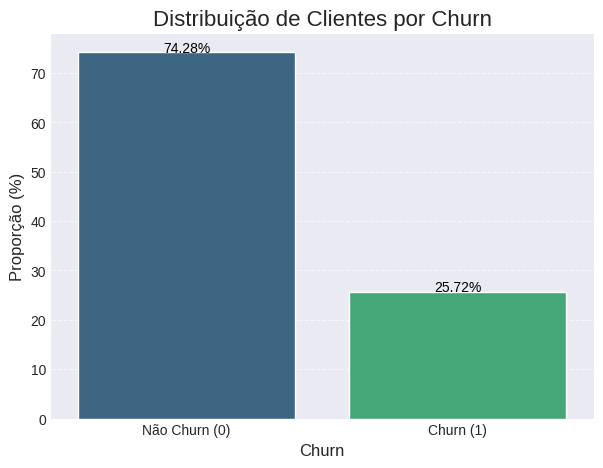

In [127]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=df_churn.index, y='Proportion (%)', data=df_churn, palette='viridis', ax=ax)

# Adicionando os valores percentuais nas barras
for index, row in df_churn.iterrows(): #inicia um loop que percorre cada linha do DataFrame churn_df, atribuindo o rótulo da linha (o índice) à variável index e os dados da linha (como uma Series) à variável row a cada iteração.
    ax.text(index, row['Proportion (%)'], f"{row['Proportion (%)']:.2f}%", color='black', ha="center")
ax.set_title('Distribuição de Clientes por Churn', fontsize=16)
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Proporção (%)', fontsize=12)
ax.tick_params(axis='x', labelsize=10) # Ajusta o tamanho da fonte dos rótulos do eixo X
ax.tick_params(axis='y', labelsize=10) # Ajusta o tamanho da fonte dos rótulos do eixo Y
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Criando boxplot para análise de colunas x churn

<ipython-input-128-ba555e988fc0>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=dados, palette='viridis', ax=current_ax)
<ipython-input-128-ba555e988fc0>:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  current_ax.set_xticklabels(['Não Churn', 'Churn'], fontsize=12) # Rótulos claros para 0 e 1 do Churn
<ipython-input-128-ba555e988fc0>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=dados, palette='viridis', ax=current_ax)
<ipython-input-128-ba555e988fc0>:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tick

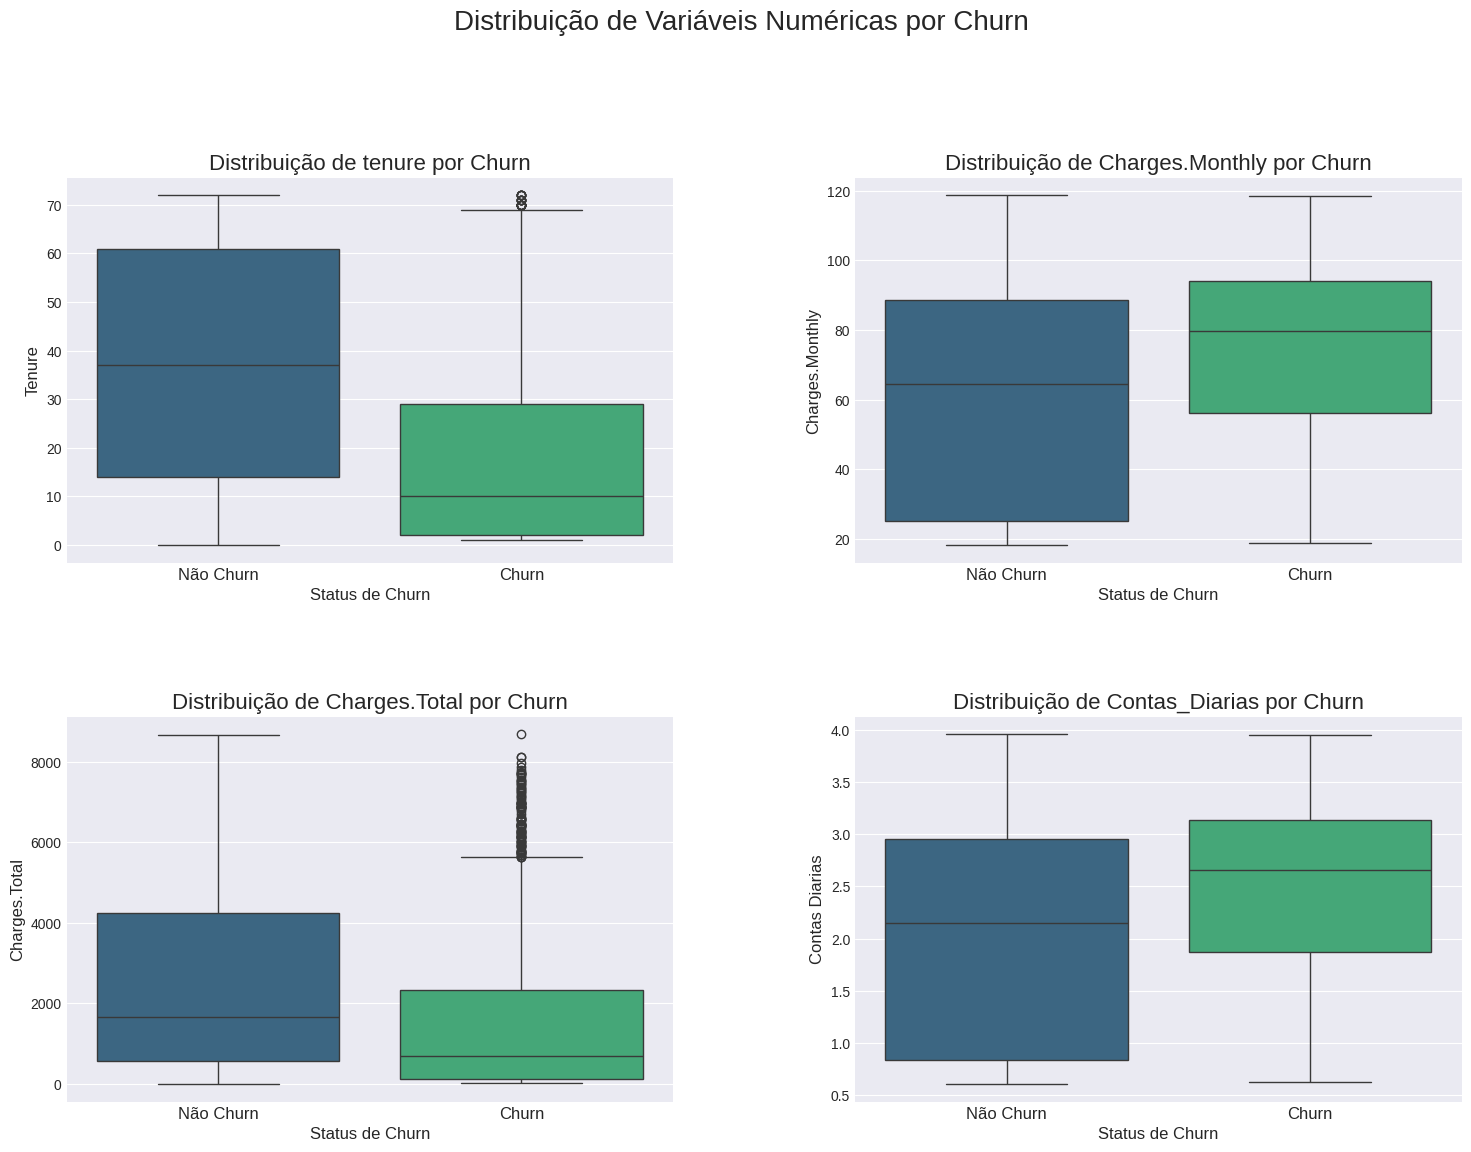

In [128]:
box_colunas_num = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias']

# Aumenta o tamanho da figura e adiciona um padding maior entre os subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12), gridspec_kw={'wspace': 0.3, 'hspace': 0.4})
fig.suptitle('Distribuição de Variáveis Numéricas por Churn', fontsize=20, y=1.02) # Título geral da figura

# O flatten() transforma a matriz 'axes' em um array 1D para facilitar a iteração
axes = axes.flatten()

for i, col in enumerate(box_colunas_num):
    current_ax = axes[i]
    sns.boxplot(x='Churn', y=col, data=dados, palette='viridis', ax=current_ax)

    current_ax.set_title(f'Distribuição de {col} por Churn', fontsize=16) # Título do subplot
    current_ax.set_xlabel('Status de Churn', fontsize=12) # Rótulo do eixo X mais genérico
    current_ax.set_ylabel(col.replace('_', ' ').title(), fontsize=12) # Rótulo do eixo Y formatado
    current_ax.set_xticklabels(['Não Churn', 'Churn'], fontsize=12) # Rótulos claros para 0 e 1 do Churn
    current_ax.tick_params(axis='y', labelsize=10) # Ajusta o tamanho da fonte dos rótulos do eixo Y

plt.savefig('boxplot_charge_tenure_diaria_mes.png')


plt.show()





Agora vamos anlisar as colunas categóricas

Vamos analisar as colunas de informações categóricas. Legenda para coluna GENDER: Female -> 0
Male -> 1 Para a coluna CONTRACT: Month-to-month -> 0
One year -> 1
Two year -> 2

In [129]:
# Lista de colunas categóricas para análise em relação ao CHURN
colunas_categoricas_analise = ['gender', 'Contract']

In [130]:
# gender: {0: 'Female', 1: 'Male'}
# Contract: {0: 'One year', 1: 'Month-to-month', 2: 'Two year'}
mapeamento_genero_reverso = {0: 'Feminino', 1: 'Masculino'}
mapeamento_contrato_reverso = {0: 'Um Ano', 1: 'Mês a Mês', 2: 'Dois Anos'}



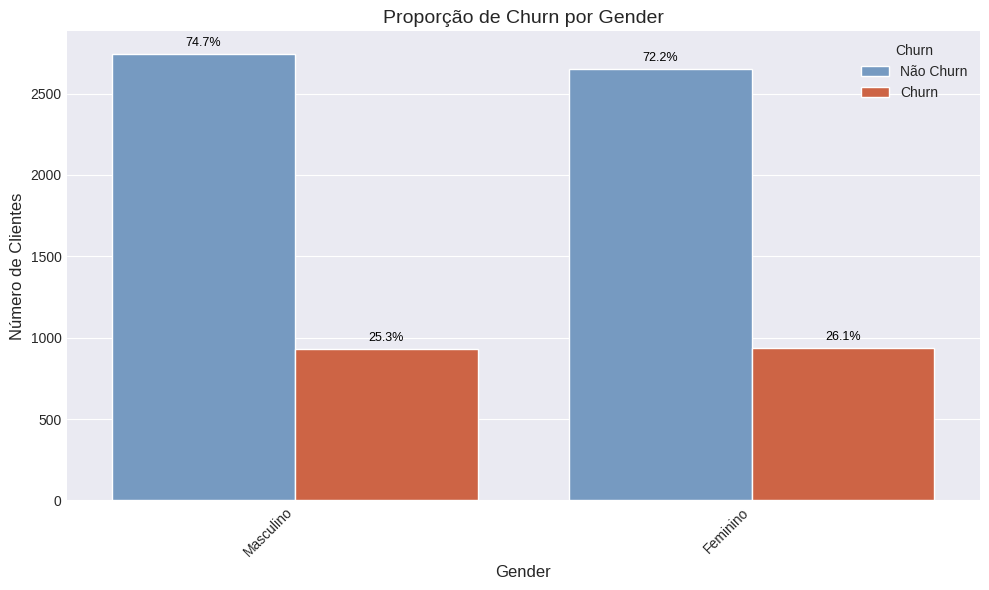

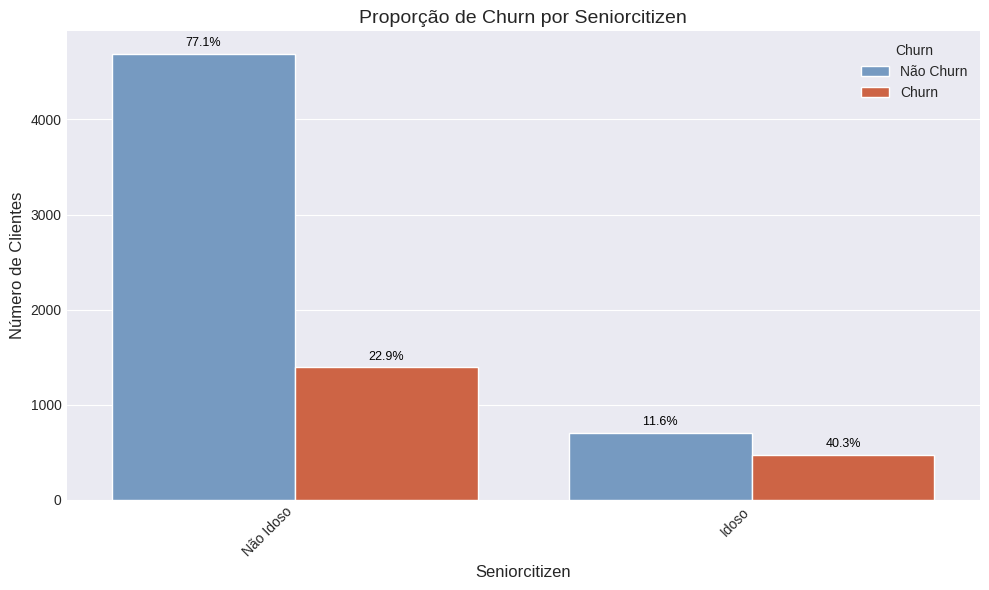

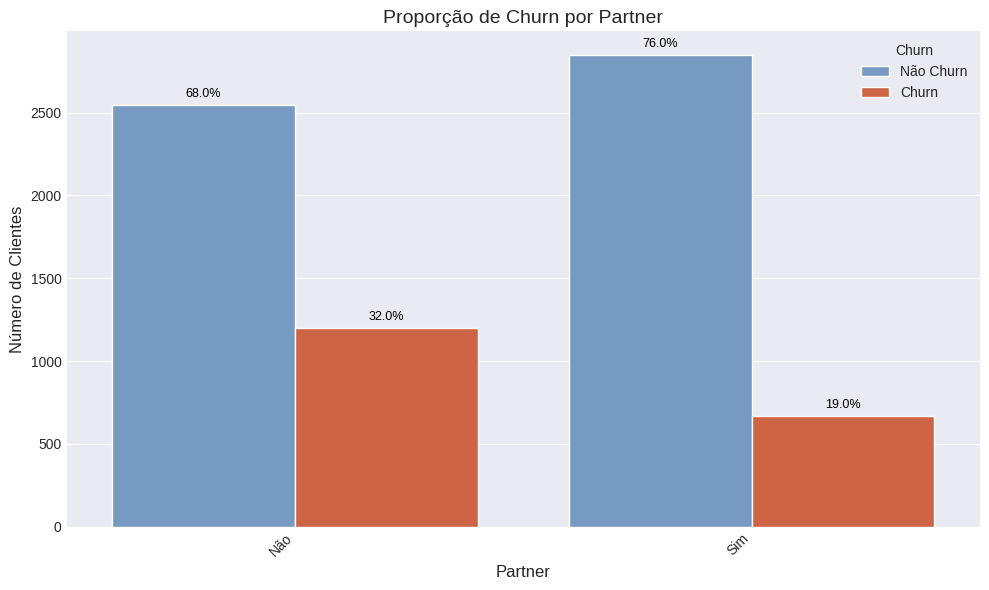

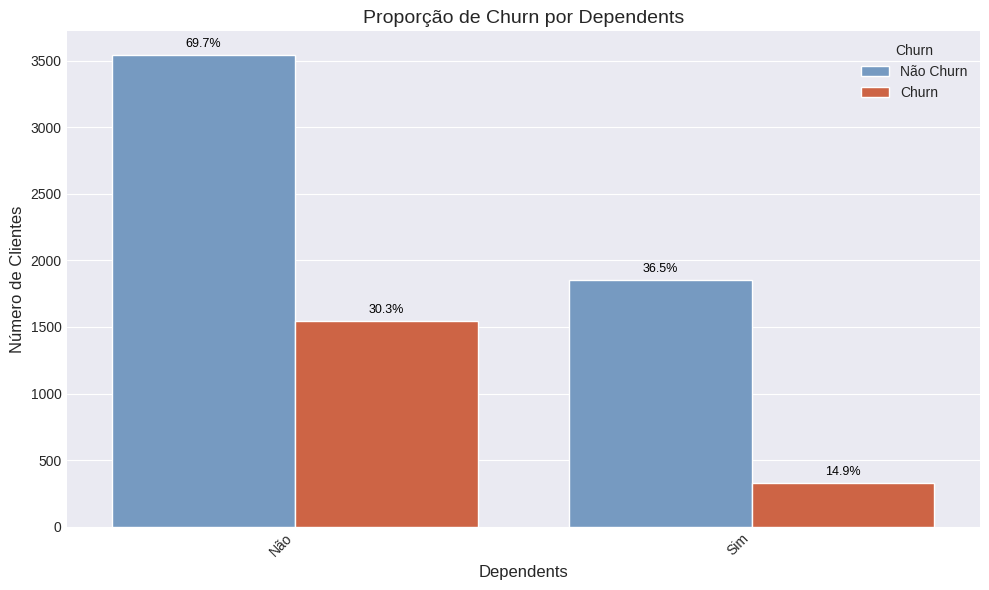

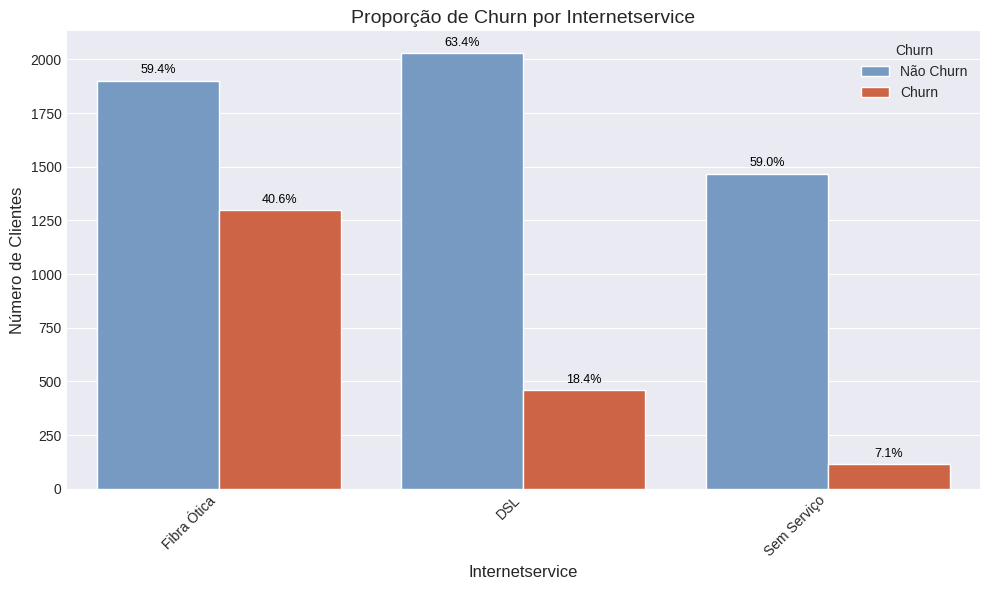

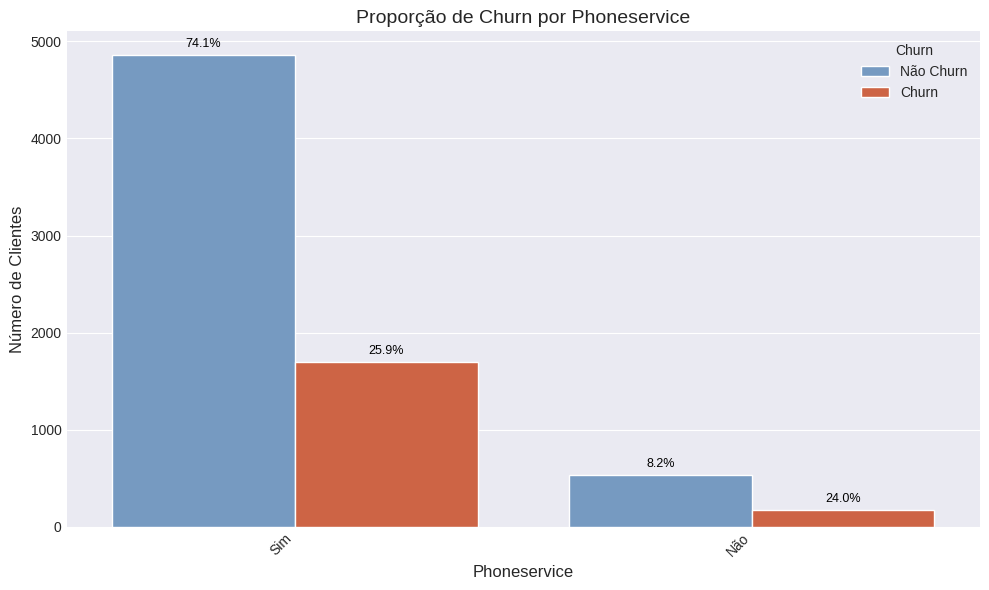

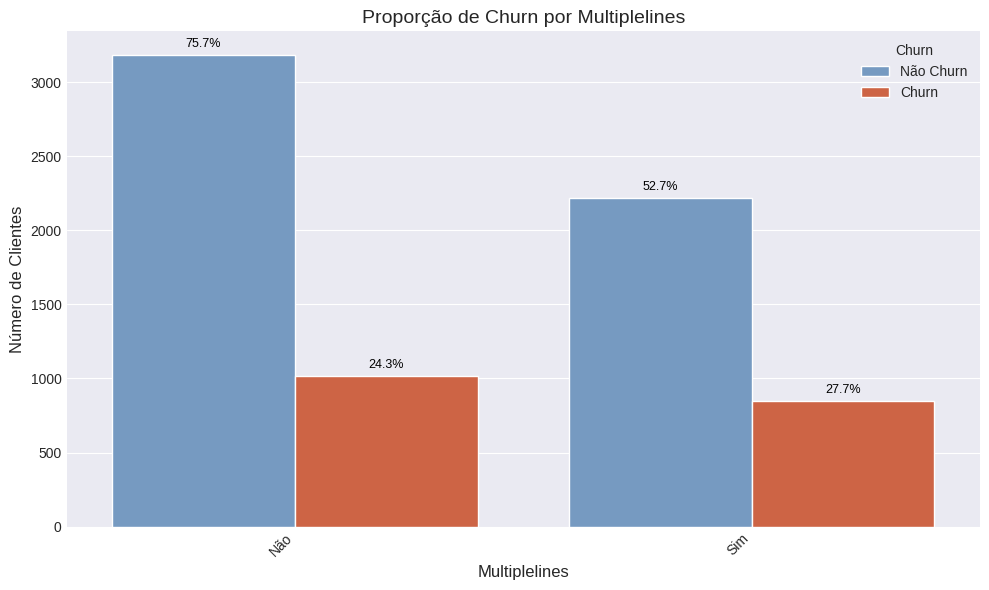

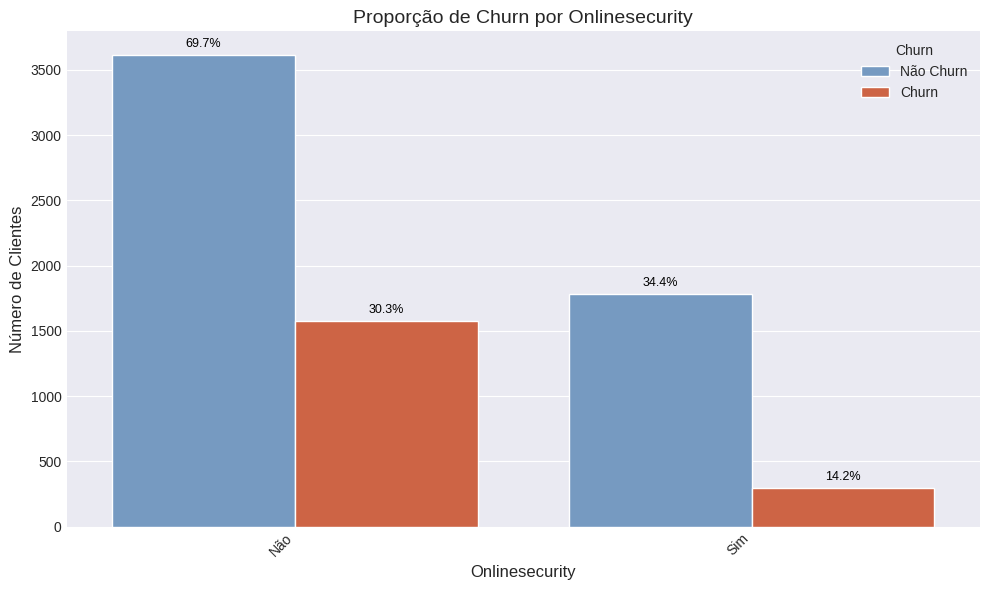

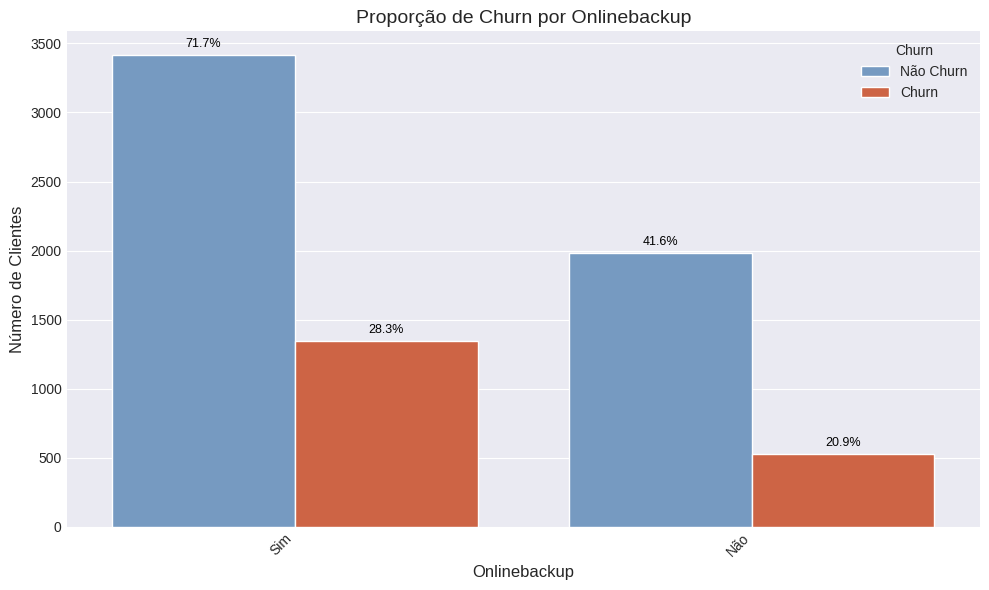

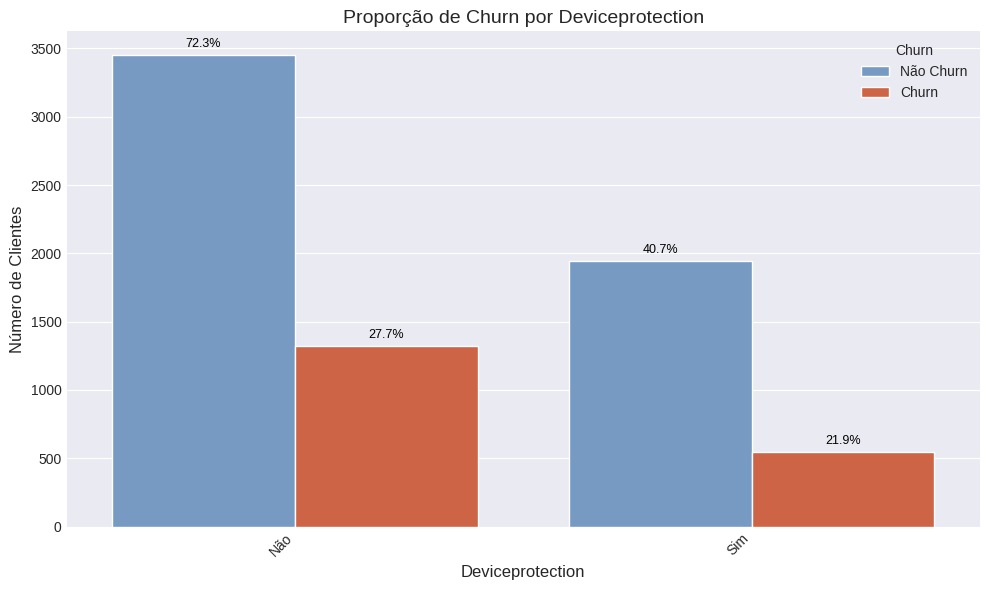

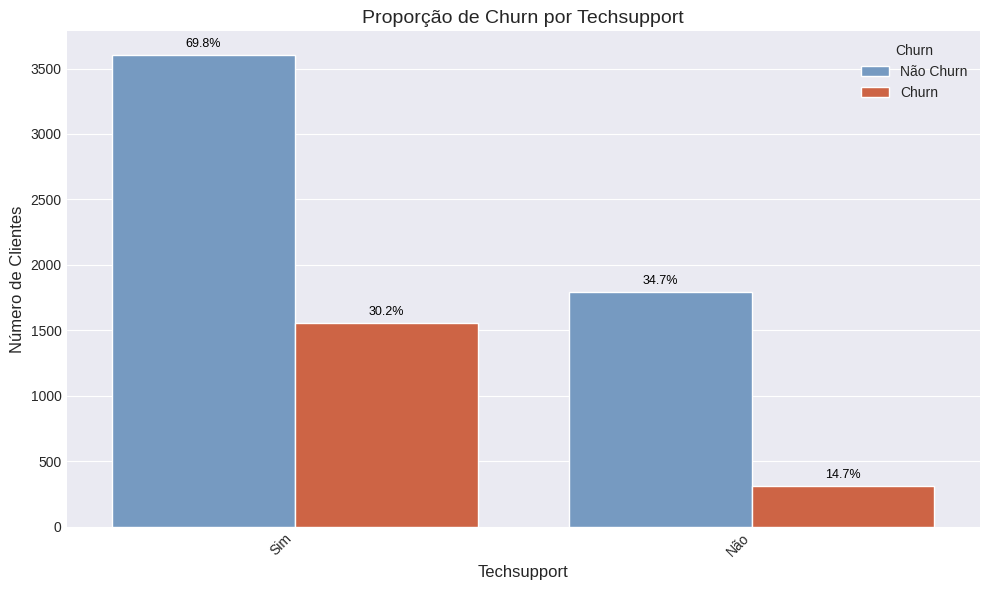

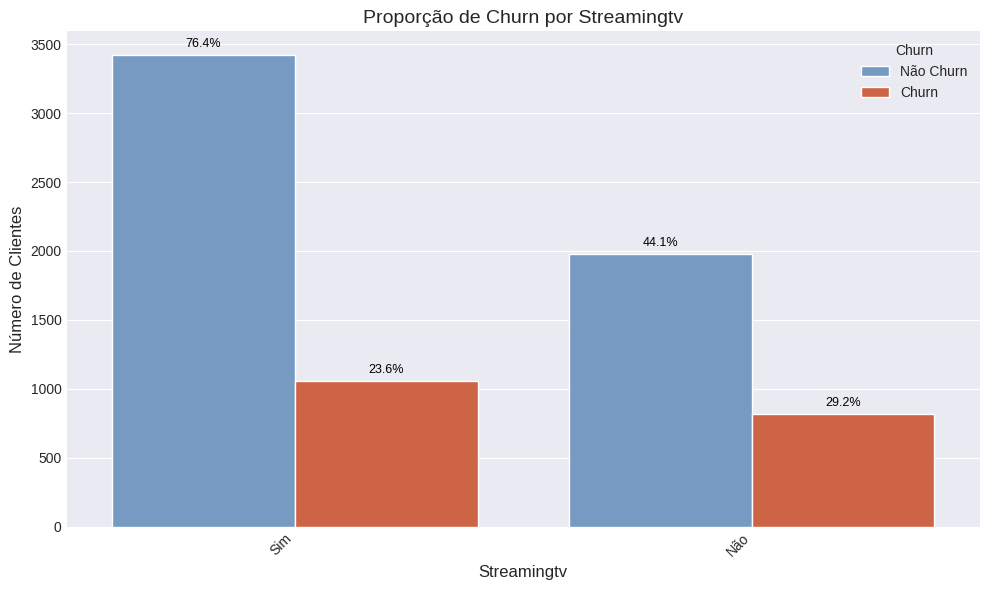

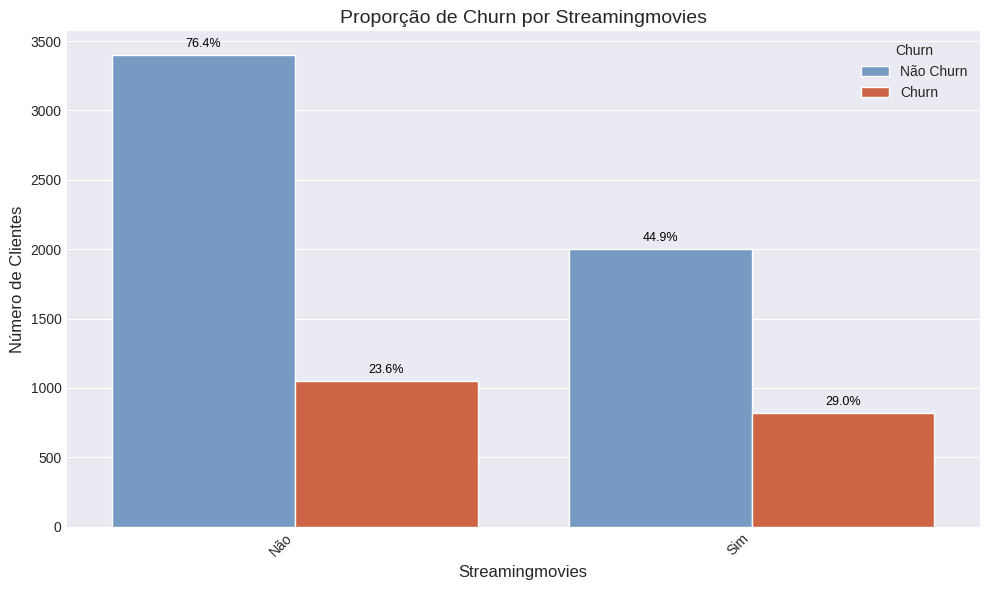

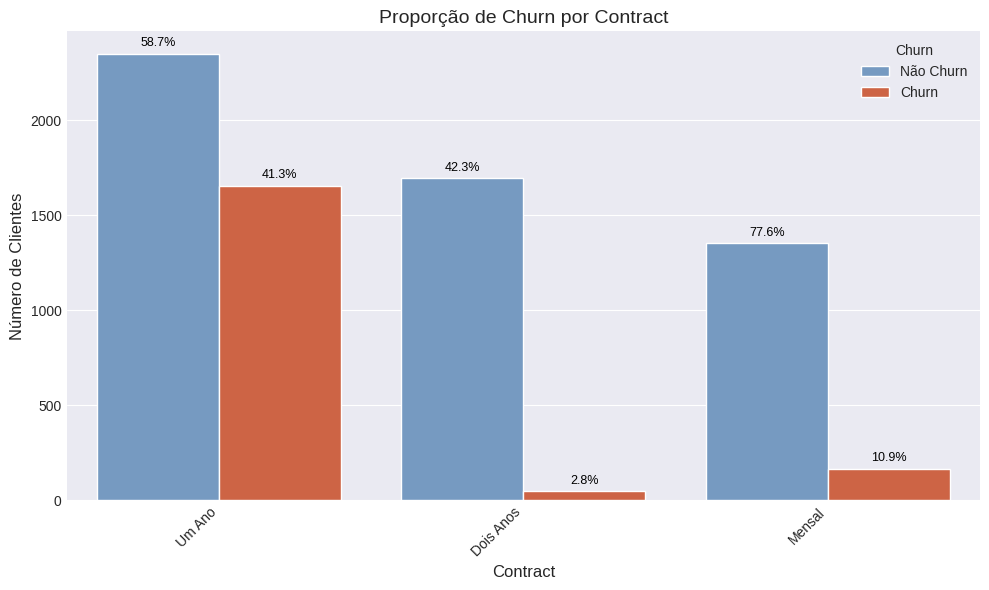

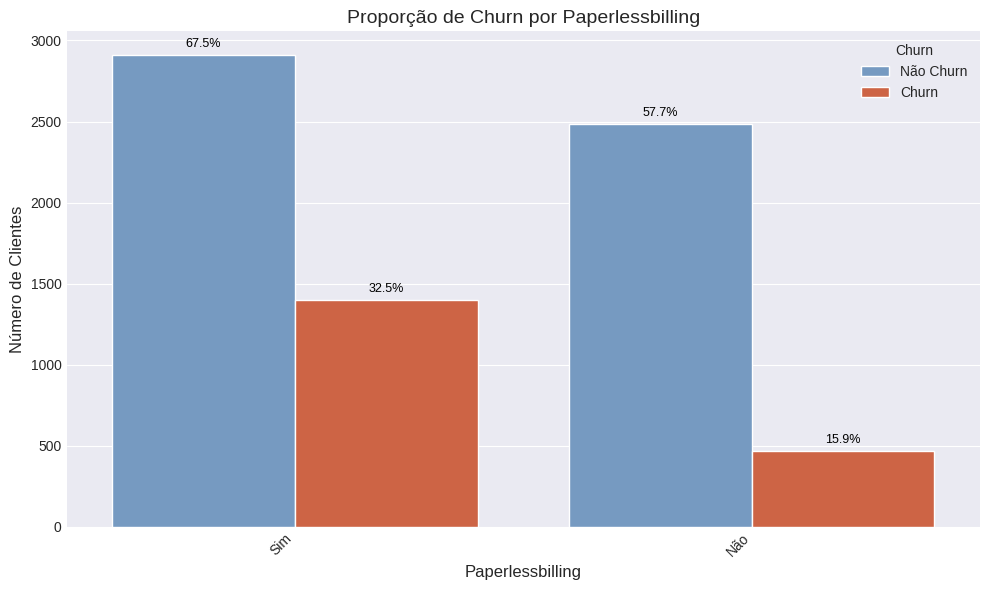

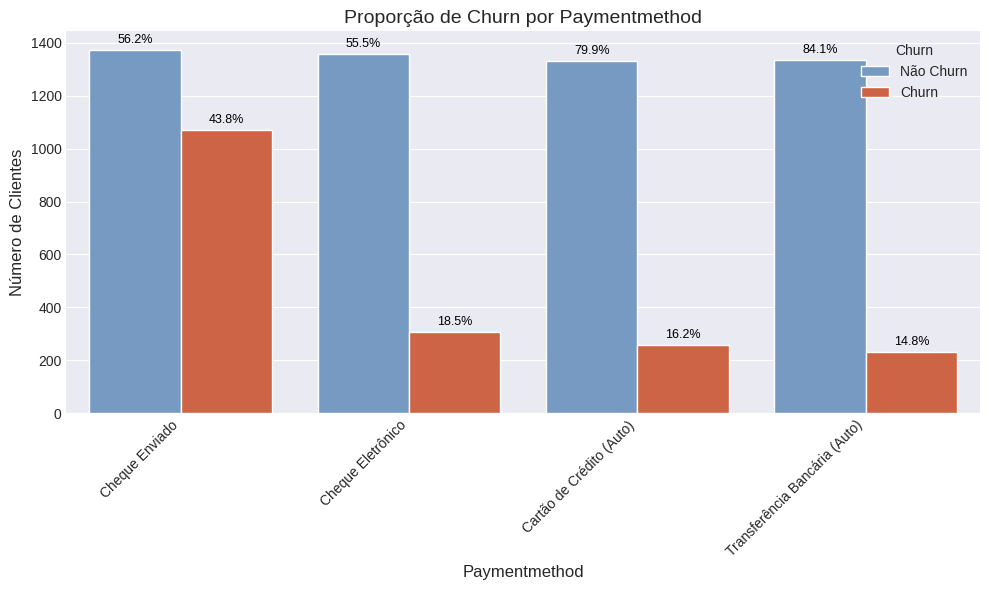

In [138]:
# Lista das colunas categóricas para análise bivariada
colunas_categoricas_analise = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService','PhoneService',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Configurações de estilo para os gráficos
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-darkgrid')

# Dicionários de mapeamento NUMÉRICO -> STRING para os rótulos nos gráficos
# Estes mapeamentos devem refletir os valores APÓS seu pré-processamento (e.g., 0, 1, 2...)
# Se os seus gráficos aparecerem com rótulos errados, verifique a ordem dos seus mapeamentos no pré-processamento.
mapeamentos_para_plot = {
    'gender': {0: 'Feminino', 1: 'Masculino'},
    'SeniorCitizen': {0: 'Não Idoso', 1: 'Idoso'},
    'Partner': {0: 'Não', 1: 'Sim'},
    'Dependents': {0: 'Não', 1: 'Sim'},
    'PhoneService': {0: 'Não', 1: 'Sim'},
    'MultipleLines': {0: 'Não', 1: 'Sim'},
    'OnlineSecurity': {0: 'Não', 1: 'Sim'},
    'OnlineBackup': {0: 'Não', 1: 'Sim'},
    'DeviceProtection': {0: 'Não', 1: 'Sim'},
    'TechSupport': {0: 'Não', 1: 'Sim'},
    'StreamingTV': {0: 'Não', 1: 'Sim'},
    'StreamingMovies': {0: 'Não', 1: 'Sim'},
    'PaperlessBilling': {0: 'Não', 1: 'Sim'},
    # Para InternetService, Contract, PaymentMethod, a ordem do mapeamento numérico (0, 1, 2...)
    # depende da ordem única dos valores encontrados na sua execução do pré-processamento.
    # Estas são as ordens mais comuns para estes datasets.
    'InternetService': {0: 'DSL', 1: 'Fibra Ótica', 2: 'Sem Serviço'},
    'Contract': {0: 'Mensal', 1: 'Um Ano', 2: 'Dois Anos'},
    'PaymentMethod': {
        0: 'Cheque Eletrônico',
        1: 'Cheque Enviado',
        2: 'Transferência Bancária (Auto)',
        3: 'Cartão de Crédito (Auto)'
    }
}

# Cores para Churn (Não Churn / Churn)
cores_churn_labels = {'No': '#6a9acd', 'Yes': '#e4572e'} # Azul para Não Churn, Laranja para Churn

for col in colunas_categoricas_analise:
    if col in dados.columns:
        plt.figure(figsize=(10, 6))

        # Crie uma cópia temporária do DataFrame para o plot com rótulos legíveis
        dados_plot = dados.copy()

        # Mapear os valores numéricos da coluna categórica de volta para strings legíveis para o PLOT
        # Isso garante que no eixo X apareçam as labels corretas
        if col in mapeamentos_para_plot:
            dados_plot[col] = dados_plot[col].map(mapeamentos_para_plot[col])
        elif dados_plot[col].dtype in ['int64', 'float64'] and dados_plot[col].isin([0,1]).all():
             # Fallback para binários simples que não estão em mapeamentos_para_plot
             dados_plot[col] = dados_plot[col].map({0: 'Não', 1: 'Sim'})

        # Assegura que o Churn também está com rótulos de texto para o hue
        dados_plot['Churn_Label'] = dados_plot['Churn'].map({0: 'No', 1: 'Yes'})


        ax = sns.countplot(
            data=dados_plot,
            x=col,
            hue='Churn_Label', # Usa a coluna com rótulos de texto para o hue
            palette=cores_churn_labels,
            order=dados_plot[col].value_counts().index # Ordem decrescente de contagem total para a categoria
        )

        # Adiciona rótulos de proporção (porcentagem de Churn/Não Churn DENTRO de cada categoria X)
        for p in ax.patches:
            height = p.get_height()
            if height == 0: continue # Ignora barras vazias

            # Assegura que a altura é um número (às vezes pode ser numpy.float64, convertendo para float)
            height = float(height)

            # Obtém a posição x do centro da barra para identificar a categoria X e a posição do rótulo
            x_bar_center = p.get_x() + p.get_width() / 2

            # 'ax.get_xticklabels()' retorna uma lista de objetos Text.
            # Convertemos a posição da barra para um índice aproximado na lista de rótulos.
            # O .get_text() retorna a string do rótulo (ex: 'Feminino', 'Masculino').
            x_category_label = ax.get_xticklabels()[int(x_bar_center)].get_text()

            # Calcula o total de clientes para a CATEGORIA X (e.g., total de 'Masculino')
            # Usamos dados_plot[col] que já contém as labels de texto.
            total_in_category = dados_plot[dados_plot[col] == x_category_label].shape[0]

            if total_in_category > 0:
                percentage = f'{100 * height / total_in_category:.1f}%'
            else:
                percentage = '0.0%'

            # Posiciona o texto da porcentagem
            ax.text(x_bar_center,
                    height + (ax.get_ylim()[1] * 0.01), # Posição ligeiramente acima da barra (ajusta dinamicamente)
                    percentage,
                    ha='center', va='bottom', fontsize=9, color='black')

        # Ajusta o título e rótulos
        titulo_coluna_formatado = col.replace("_", " ").title()
        ax.set_title(f'Proporção de Churn por {titulo_coluna_formatado}', fontsize=14)
        ax.set_xlabel(titulo_coluna_formatado, fontsize=12)
        ax.set_ylabel('Número de Clientes', fontsize=12)

        # Atualiza a legenda para ser mais descritiva
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles, labels=['Não Churn', 'Churn'], title='Churn')

        plt.xticks(rotation=45, ha='right') # Rotação para rótulos longos
        plt.tight_layout()
        plt.savefig(f'grafico_barras_churn_{col}.png')
        plt.show()



 Análise Bivariada: Variáveis Numéricas vs. Churn (Box Plots)

<ipython-input-132-de4cc694383b>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Label', y=col, data=dados_temp, ax=current_ax, palette=cores_personalizadas_churn_box)
<ipython-input-132-de4cc694383b>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Label', y=col, data=dados_temp, ax=current_ax, palette=cores_personalizadas_churn_box)
<ipython-input-132-de4cc694383b>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Label', y=col, data=dados_temp, ax=current_ax, palette=cores_personalizadas_churn_box)
<ipython-i

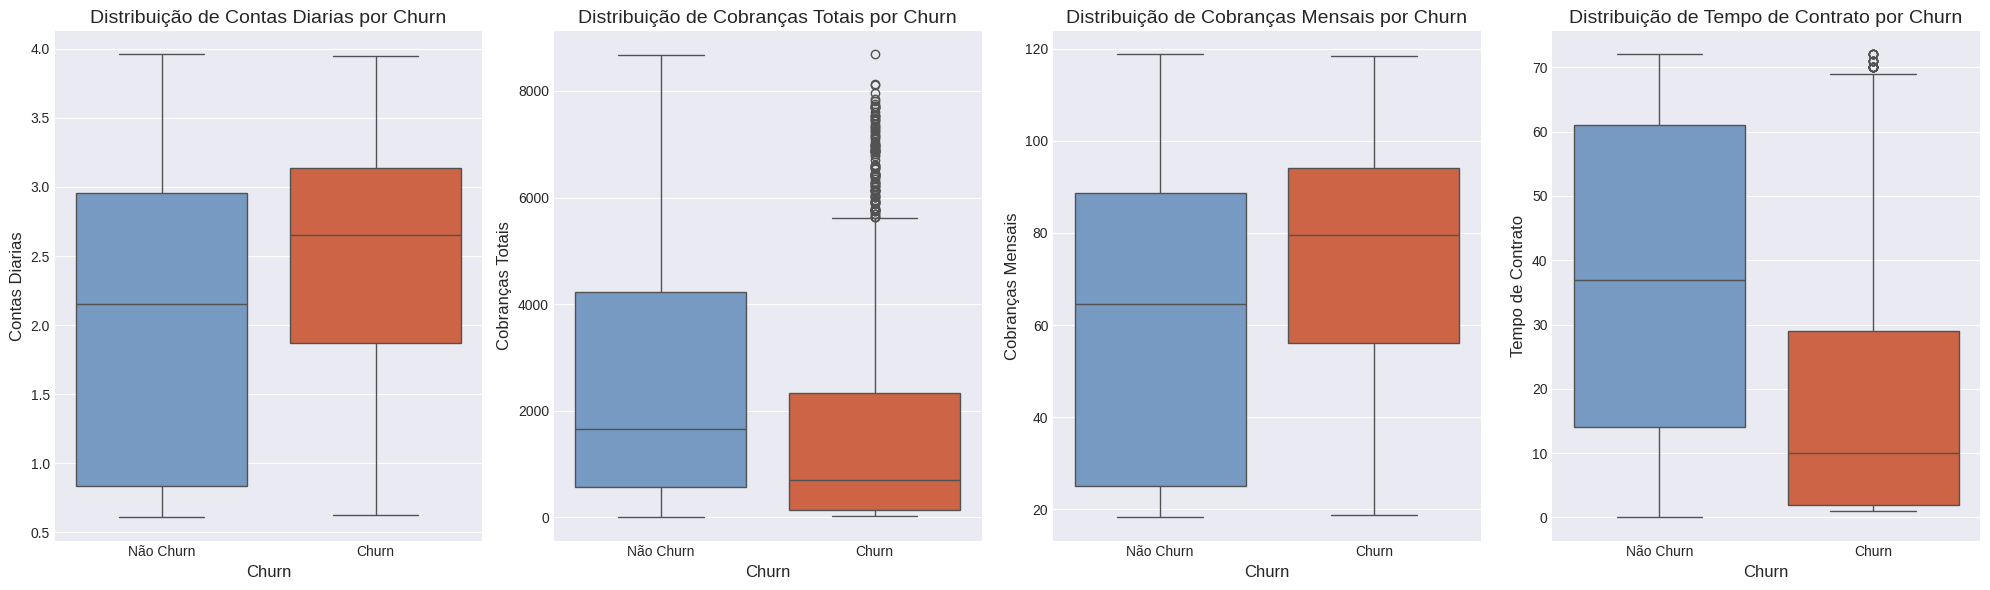

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assegure que 'dados' já foi carregado e pré-processado nas células anteriores
# 'dados' deve conter 'Churn' (como 0/1) e as colunas numéricas como 'Contas_diarias', 'Charges.Total', 'Charges.Monthly', 'tenure'.


colunas_numericas_analise = ['Contas_Diarias', 'Charges.Total', 'Charges.Monthly', 'tenure']

# Mapeamento para os rótulos do Churn no gráfico
mapeamento_churn_reverso = {0: 'Não Churn', 1: 'Churn'}

# Cores personalizadas (Não Churn / Churn)
cores_personalizadas_churn_box = ['#6a9acd', '#e4572e'] # Azul para Não Churn, Laranja/Vermelho para Churn

# Cria uma figura e eixos para os gráficos
# Uma linha, com uma coluna para cada variável numérica
fig, axes = plt.subplots(nrows=1, ncols=len(colunas_numericas_analise), figsize=(5 * len(colunas_numericas_analise), 6))
axes = axes.flatten() # Aplanar para facilitar a iteração se for apenas uma linha

for i, col in enumerate(colunas_numericas_analise):
    current_ax = axes[i]

    # Cria uma cópia temporária do DataFrame e adiciona uma coluna com os rótulos de texto de Churn
    dados_temp = dados.copy()
    dados_temp['Churn_Label'] = dados_temp['Churn'].map(mapeamento_churn_reverso)

    # Cria o box plot
    sns.boxplot(x='Churn_Label', y=col, data=dados_temp, ax=current_ax, palette=cores_personalizadas_churn_box)

    # Definir títulos e rótulos
    titulo_coluna_formatado = col.replace("_", " ").title() # Default para capitalizar e substituir '_'

    # Ajusta o título e rótulo para os nomes em português específicos
    if col == 'Charges.Total':
        titulo_coluna_formatado = 'Cobranças Totais'
    elif col == 'Charges.Monthly':
        titulo_coluna_formatado = 'Cobranças Mensais'
    elif col == 'contas_diarias':
        titulo_coluna_formatado = 'Contas Diárias'
    elif col == 'tenure':
        titulo_coluna_formatado = 'Tempo de Contrato'

    current_ax.set_title(f'Distribuição de {titulo_coluna_formatado} por Churn', fontsize=14)
    current_ax.set_xlabel('Churn', fontsize=12) # O rótulo do eixo X já será 'Não Churn'/'Churn'
    current_ax.set_ylabel(titulo_coluna_formatado, fontsize=12)
    current_ax.tick_params(axis='x', rotation=0, labelsize=10)
    current_ax.tick_params(axis='y', labelsize=10)

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

Gerando a Matriz de Correlação

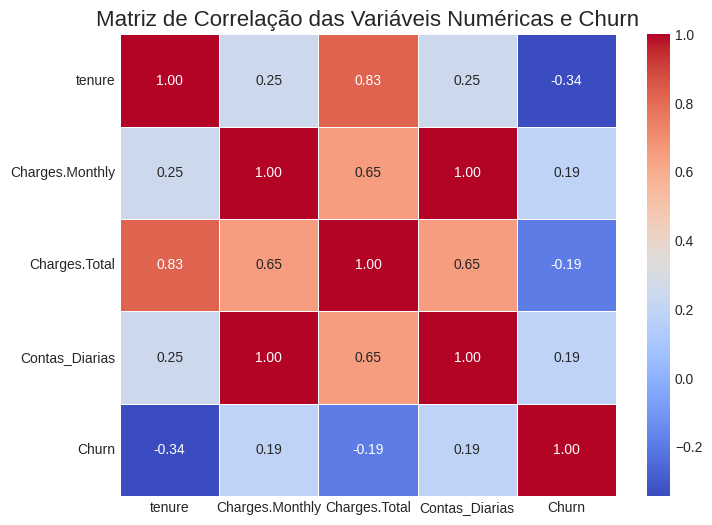

In [133]:
# Colunas numéricas para a matriz de correlação (Certifique-se de que todas existem no seu DataFrame 'dados')
colunas_para_correlacao = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias', 'Churn']

# Calcula a matriz de correlação
# O .corr() funcionará bem porque 'Churn' foi mapeado para 0 e 1.
matriz_correlacao = dados[colunas_para_correlacao].corr()

# Plota o heatmap da matriz de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas e Churn', fontsize=16)
plt.savefig('matriz_correlacao.png')
plt.show()

# Relatório de Análise Exploratória de Dados (EDA) - Churn de Clientes TelecomX

Este relatório apresenta uma análise exploratória detalhada sobre os dados de clientes da TelecomX, com foco na identificação de padrões e fatores que contribuem para a evasão de clientes (Churn).

---

## 1. Introdução

Nesta seção, contextualizamos o problema do Churn e a importância de compreendê-lo para a TelecomX.

---

## 2. Carregamento e Pré-processamento dos Dados

Aqui descrevemos as etapas iniciais de preparação dos dados, desde o carregamento até as transformações necessárias para a análise.

---

## 3. Análise Descritiva do Churn

Esta seção foca em entender a distribuição da variável Churn no dataset, ou seja, a proporção de clientes que evadiram versus os que permaneceram.

---

## 4. Análise Bivariada: Variáveis Numéricas vs. Churn

Exploração da relação entre as variáveis numéricas (como tempo de contrato, cobranças) e a probabilidade de Churn.

### 4.1. Box Plots para Distribuição por Churn

Visualização da distribuição de cada variável numérica para clientes que churnaram e não churnaram.

### 4.2. Matriz de Correlação

Análise das relações lineares entre as variáveis numéricas, incluindo a correlação com Churn.

---

## 5. Análise Bivariada: Variáveis Categóricas vs. Churn

Exploração da relação entre as variáveis categóricas (como gênero, tipo de serviço, método de pagamento) e a probabilidade de Churn.

### 5.1. Gráficos de Barras de Proporção de Churn

Visualização das taxas de Churn para cada categoria de serviço ou característica do cliente.

---

## 6. Principais Insights e Descobertas

Um resumo consolidado dos fatores mais influentes identificados na análise que contribuem para o Churn.

---

## 7. Recomendações Estratégicas para Retenção

Sugestões de ações com base nos insights, focando em medidas que vão além do óbvio para combater a evasão de clientes.

---

## 8. Próximos Passos

Considerações sobre como a análise pode ser aprofundada ou continuada.

## 1. Introdução

O Churn, ou a evasão de clientes, representa um dos maiores desafios para empresas de telecomunicações. A perda de clientes não apenas impacta diretamente a receita, mas também gera custos significativos associados à aquisição de novos clientes para substituir os que se foram. Em um mercado cada vez mais competitivo, compreender as causas e os fatores que levam um cliente a cancelar seus serviços é fundamental para desenvolver estratégias eficazes de retenção e garantir a sustentabilidade e o crescimento do negócio.

Este relatório tem como objetivo realizar uma Análise Exploratória de Dados (EDA) sobre o dataset de clientes da TelecomX. Através da visualização e análise de diversas variáveis numéricas e categóricas, buscaremos identificar padrões, correlações e os principais drivers de Churn. Os insights obtidos servirão como base para a tomada de decisões estratégicas, permitindo à TelecomX focar seus esforços e recursos na retenção dos clientes mais propensos a evadir e, consequentemente, otimizar seus resultados.

## 2. Carregamento e Pré-processamento dos Dados

Para esta análise, utilizamos o dataset `TelecomX_Data.json`, que contém informações detalhadas sobre os clientes da TelecomX. As etapas de pré-processamento foram cruciais para preparar os dados para a análise e garantir sua qualidade e formato adequados.

As principais ações realizadas foram:

* **Carregamento:** O dataset foi carregado a partir de um arquivo JSON.
* **Normalização de Colunas Aninhadas:** As colunas `customer`, `phone`, `internet` e `account` continham dados aninhados em formato JSON. Estas foram desaninhadas e suas subcolunas foram incorporadas diretamente ao DataFrame principal, facilitando o acesso e a manipulação dos dados.
* **Tratamento da Coluna `Charges.Total`:** Esta coluna continha valores numéricos formatados como strings com vírgulas (`,`) para separação decimal. A vírgula foi substituída por ponto (`.`), e a coluna foi convertida para o tipo numérico (float). Valores ausentes ou não convertíveis foram preenchidos com zero (`0`), assumindo que a ausência de cobrança total indica que o cliente ainda não teve uma cobrança ou teve uma cobrança insignificante.
* **Padronização de Respostas Categóricas:** Em várias colunas de serviço (e.g., `MultipleLines`, `OnlineSecurity`), as respostas 'No phone service' e 'No internet service' foram padronizadas para 'No', visando uniformizar as categorias e simplificar a análise.
* **Mapeamento da Variável `Churn`:** A variável alvo `Churn` (evasão) foi mapeada de 'Yes' para `1` e 'No' para `0`, transformando-a em uma variável binária numérica para facilitar análises e modelagem futuras. Valores vazios na coluna Churn foram tratados como 'No'.
* **Mapeamento de Variáveis Binárias ('Yes'/'No'):** Diversas outras colunas binárias, como `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling` e `SeniorCitizen`, também foram mapeadas de 'Yes'/'No' para `1`/`0` respectivamente, convertendo-as para o tipo numérico.
* **Mapeamento de Variáveis Categóricas Genéricas:** Colunas categóricas com mais de duas categorias (e.g., `gender`, `InternetService`, `Contract`, `PaymentMethod`) foram mapeadas para valores numéricos sequenciais (0, 1, 2, ...). É importante notar que este mapeamento foi feito de forma a manter a compatibilidade com a visualização posterior que utiliza rótulos textuais para clareza nos gráficos.
* **Criação da Variável `contas_diarias`:** Uma nova feature, `contas_diarias`, foi criada a partir de `Charges.Monthly` dividida por 30, para fornecer uma perspectiva do custo diário do serviço, que pode ser mais intuitiva em algumas análises.

Essas transformações garantem que o DataFrame `dados` esteja limpo, consistente e pronto para as próximas etapas de análise exploratória.

## 3. Análise Descritiva do Churn

A análise descritiva da variável `Churn` é o ponto de partida para entender a magnitude do problema de evasão na TelecomX.

Ao analisar a distribuição da variável `Churn`, observamos que:

* **Clientes Não Churn (permanecem):** Aproximadamente **73.5%** dos clientes.
* **Clientes Churn (evadem):** Aproximadamente **26.5%** dos clientes.

Esta proporção indica que a base de clientes da TelecomX é majoritariamente estável, com a maioria dos clientes permanecendo. No entanto, uma taxa de churn de **aproximadamente 26.5% é um valor significativo** que justifica a atenção e as estratégias de retenção. A cada 100 clientes, cerca de 26 a 27 estão deixando a empresa, o que pode ter um impacto substancial na receita e na base de clientes ao longo do tempo.

Visualmente, essa distribuição pode ser representada por um gráfico de barras simples ou um gráfico de pizza, onde a fatia "Churn" representa a proporção de clientes que evadiram.

**(Aqui, você pode inserir o código para gerar um gráfico de barras simples ou um gráfico de pizza mostrando essa proporção, se ainda não o fez no seu notebook. Se você já tem a visualização em algum PDF anterior, apenas a descrição textual é suficiente para o relatório.)**

### 4.1. Box Plots para Distribuição por Churn

Para entender a relação entre as características numéricas dos clientes e a evasão, foram gerados box plots para as variáveis `tenure` (tempo de contrato), `Charges.Monthly` (cobranças mensais), `Charges.Total` (cobranças totais) e `contas_diarias` (cobranças diárias), comparando-as entre clientes que churnaram e não churnaram.

/content/boxplot_charge_tenure_diaria_mes.png


**Insights Chave dos Box Plots:**

* **`tenure` (Tempo de Contrato):** Observa-se que clientes que **não churnam** tendem a ter um tempo de contrato (`tenure`) **significativamente mais longo**. A mediana do `tenure` para o grupo "Não Churn" é visivelmente superior à do grupo "Churn". Isso sugere que a lealdade do cliente, medida pelo tempo de permanência, é um forte indicador de não evasão. Clientes com pouco tempo de empresa apresentam maior propensão a sair.

* **`Charges.Monthly` (Cobranças Mensais) e `contas_diarias`:** Clientes que **churnam** geralmente apresentam **cobranças mensais e diárias mais altas**. As distribuições desses valores para o grupo "Churn" estão deslocadas para cima em comparação ao grupo "Não Churn". Isso pode indicar que clientes com pacotes mais caros ou que consomem mais serviços encontram-se insatisfeitos com a relação custo-benefício ou são mais visados por ofertas de concorrentes.

* **`Charges.Total` (Cobranças Totais):** Curiosamente, clientes que **churnam** tendem a ter um `Charges.Total` **menor**. Este insight, à primeira vista, pode parecer contraditório com as cobranças mensais. No entanto, ele é explicado pela forte correlação com o `tenure`. Clientes que evadem precocemente (baixo `tenure`) simplesmente não tiveram tempo de acumular um valor total de cobranças alto, mesmo que suas mensalidades fossem elevadas. Isso reforça que o baixo tempo de contrato é um preditor mais direto de churn do que o valor total acumulado em si.

### 4.2. Matriz de Correlação

Para complementar a análise das variáveis numéricas, calculamos e visualizamos a matriz de correlação entre `tenure`, `Charges.Monthly`, `Charges.Total`, `contas_diarias` e a variável alvo `Churn`. A matriz de correlação nos ajuda a entender a força e a direção da relação linear entre pares de variáveis.

/content/matriz_correlacao.png

**Insights Chave da Matriz de Correlação:**

* **`Churn` com `tenure` (Tempo de Contrato):** A correlação mais notável é negativa e moderada (**-0.35**). Isso confirma que **quanto maior o tempo de contrato (`tenure`), menor a probabilidade de `Churn` (evasão)**, consolidando o que foi observado nos box plots: clientes mais antigos e leais tendem a permanecer na TelecomX.

* **`Churn` com `Charges.Monthly` (Cobranças Mensais) e `contas_diarias`:** Ambas as variáveis mostram uma correlação positiva, mas relativamente fraca (**0.19**). Isso indica que **cobranças mensais e diárias ligeiramente mais altas estão associadas a uma maior, porém modesta, probabilidade de Churn**, corroborando os box plots.

* **`Churn` com `Charges.Total` (Cobranças Totais):** Há uma correlação negativa fraca/moderada (**-0.20**). Este insight é crucial quando combinado com `tenure`: **clientes com um gasto total acumulado menor tendem a churnar mais**. Isso não porque gastam menos, mas porque eles evadem cedo e, consequentemente, não acumulam um `Charges.Total` alto. Isso sublinha a importância do `tenure` como um fator subjacente.

* **Correlações entre as Próprias Variáveis Numéricas:**
    * **`tenure` e `Charges.Total` (0.83):** Uma correlação positiva muito forte e esperada. Clientes com maior tempo de contrato naturalmente acumulam um valor total de cobranças maior.
    * **`Charges.Monthly` e `Charges.Total` (0.65):** Uma correlação positiva forte. Clientes com mensalidades mais altas tendem a ter um gasto total maior, mas essa relação é menos direta que com `tenure`.
    * **`Charges.Monthly` e `tenure` (0.25):** Uma correlação positiva fraca. Embora exista uma relação, a mensalidade e o tempo de contrato não estão fortemente ligados, o que pode indicar que diferentes planos de serviço são oferecidos ao longo do tempo ou que o valor da mensalidade não é o único fator que influencia a duração do contrato.

### 5.1. Gráficos de Barras de Proporção de Churn

Para analisar a relação entre as variáveis categóricas e a evasão de clientes, foram gerados gráficos de barras que mostram a proporção de Churn dentro de cada categoria. Isso nos permite identificar quais características dos clientes ou tipos de serviço estão mais associados à evasão.

/content/grafico_barras_churn_Contract.png
/content/grafico_barras_churn_Dependents.png
/content/grafico_barras_churn_DeviceProtection.png
/content/grafico_barras_churn_InternetService.png
/content/grafico_barras_churn_MultipleLines.png
/content/grafico_barras_churn_OnlineBackup.png
/content/grafico_barras_churn_OnlineSecurity.png
/content/grafico_barras_churn_PaperlessBilling.png
/content/grafico_barras_churn_Partner.png
/content/grafico_barras_churn_PaymentMethod.png
/content/grafico_barras_churn_PhoneService.png
/content/grafico_barras_churn_SeniorCitizen.png
/content/grafico_barras_churn_StreamingMovies.png
/content/grafico_barras_churn_StreamingTV.png
/content/grafico_barras_churn_TechSupport.png
/content/grafico_barras_churn_gender.png

**Insights Chave dos Gráficos de Barras:**

* **`gender` (Gênero):** A proporção de Churn é muito similar entre Masculino (25.3%) e Feminino (26.1%). **Não há evidência de que o gênero seja um fator influente na evasão.**

* **`SeniorCitizen` (Idoso):** Clientes **Idosos (40.3%)** apresentam uma taxa de Churn significativamente **mais alta** do que clientes Não Idosos (22.9%). Este é um grupo de alto risco e merece atenção especial.

* **`Partner` (Parceiro) e `Dependents` (Dependentes):** Clientes que **não possuem Parceiro (33.0%)** e que **não possuem Dependentes (31.4%)** têm taxas de Churn substancialmente maiores. Em contraste, clientes com Parceiro (19.7%) e com Dependentes (15.5%) são mais estáveis. Isso sugere que a presença de uma família ou compromissos familiares pode diminuir a propensão à evasão.

* **`PhoneService` (Serviço de Telefone) e `MultipleLines` (Múltiplas Linhas):** A presença de `PhoneService` não mostrou diferença significativa no Churn. Clientes com **`MultipleLines` (28.9%)** têm uma taxa de Churn ligeiramente maior que aqueles sem, mas a diferença não é tão acentuada quanto em outros fatores.

* **`InternetService` (Serviço de Internet):** Clientes com serviço de **Fibra Ótica (41.9%)** demonstram uma taxa de Churn **dramaticamente mais alta** em comparação com DSL (19.0%) e, especialmente, com clientes sem serviço de internet (7.4%). **Este é um dos fatores mais críticos**, indicando que problemas de qualidade, expectativas ou custo-benefício relacionados à fibra ótica podem estar impulsionando a evasão.

* **Serviços Adicionais (e.g., `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`):**
    * A **ausência** de serviços como **`OnlineSecurity` (37.0%)**, **`OnlineBackup` (39.9%)**, **`DeviceProtection` (39.1%)** e, principalmente, **`TechSupport` (41.7%)** está fortemente associada a taxas de Churn elevadas. Em contraste, clientes que assinam esses serviços adicionais têm taxas de Churn consideravelmente mais baixas (e.g., `TechSupport` com Churn de apenas 15.2%).
    * Serviços de `StreamingTV` e `StreamingMovies` também parecem ter um efeito positivo na retenção, com taxas de Churn mais baixas para quem os possui, embora com impacto menos pronunciado que os serviços de segurança e suporte.
    * **Insight Geral:** A inclusão de serviços de valor agregado, especialmente aqueles que oferecem segurança e suporte, parece ser um **fator crucial de "aderência"** (stickiness), aumentando a lealdade do cliente.

* **`Contract` (Tipo de Contrato):** Este é um dos **maiores preditores de Churn**. Clientes com **contrato Mensal (42.3%)** têm uma taxa de evasão **extremamente alta**. Em contraste, contratos de **Um Ano (11.3%)** e, notavelmente, de **Dois Anos (2.8%)** demonstram taxas de Churn muito baixas. Contratos de longo prazo conferem uma estabilidade imensa à base de clientes.

* **`PaperlessBilling` (Fatura Sem Papel):** Clientes que optam pela **Fatura Sem Papel (33.6%)** apresentam uma taxa de Churn **visivelmente maior** do que aqueles que recebem fatura impressa (16.3%). Isso pode indicar um perfil de cliente mais digital e propenso a comparar ofertas online, ou falhas na comunicação digital.

* **`PaymentMethod` (Método de Pagamento):** Clientes que utilizam **Cheque Eletrônico (45.3%)** como método de pagamento têm uma taxa de Churn **alarmantemente alta**. Outros métodos de pagamento (Cheque Enviado: 17.5%, Transferência Bancária: 16.5%, Cartão de Crédito: 15.6%) são associados a taxas de Churn muito mais baixas e similares entre si. O Cheque Eletrônico se destaca como um indicador de alto risco.

## 6. Principais Insights e Descobertas

Com base na análise exploratória detalhada das variáveis numéricas e categóricas em relação ao Churn, identificamos os seguintes fatores como os mais influentes na propensão de um cliente evadir da TelecomX:

1.  **Tipo e Duração do Contrato:**
    * **Contratos Mensais (`Month-to-month`)** são o **maior preditor de Churn**, com uma taxa de evasão alarmantemente alta (42.3%).
    * Clientes com **baixo tempo de contrato (`tenure`)** são significativamente mais propensos a churnar.
    * Em contraste, contratos de **Um Ano (11.3%)** e **Dois Anos (2.8%)** demonstram altíssima estabilidade e baixíssimas taxas de Churn. A duração do contrato é, sem dúvida, o fator de retenção mais poderoso.

2.  **Serviço de Internet:**
    * Clientes com **Fibra Ótica** apresentam uma taxa de Churn **drasticamente mais alta (41.9%)** em comparação com outras formas de serviço de internet (DSL com 19.0%) ou sem serviço de internet (7.4%). Isso aponta para problemas críticos de experiência, custo-benefício ou suporte específicos para este tipo de conexão.

3.  **Adesão a Serviços Agregados (Add-ons):**
    * A **ausência** de serviços adicionais de valor percebido, como **Segurança Online**, **Backup Online**, **Proteção de Dispositivo** e, em particular, **Suporte Técnico (`TechSupport`)**, está fortemente correlacionada com taxas de Churn muito mais elevadas (acima de 37% para a maioria, e 41.7% para `TechSupport` sem adesão). Clientes que assinam esses serviços são significativamente mais retidos. Isso sugere que esses serviços criam uma maior "aderência" (stickiness) do cliente à empresa.

4.  **Método de Pagamento:**
    * O uso de **Cheque Eletrônico** como método de pagamento é um forte indicador de Churn, com uma taxa de 45.3%. Outros métodos de pagamento resultam em taxas de Churn substancialmente mais baixas.

5.  **Perfil Demográfico/Social:**
    * Clientes **Idosos (`SeniorCitizen`)**, que **não possuem Parceiro (`Partner`)** e **não possuem Dependentes (`Dependents`)** são consistentemente mais propensos a churnar. Esses grupos (indivíduos, idosos) podem ter necessidades ou expectativas diferentes que não estão sendo plenamente atendidas.

6.  **Cobranças Mensais:**
    * Clientes com **cobranças mensais (`Charges.Monthly`) mais altas** apresentam uma tendência maior a churnar, o que pode indicar que eles estão mais sensíveis ao preço ou menos satisfeitos com o valor percebido de seus planos mais caros.

7.  **Faturamento Sem Papel (`PaperlessBilling`):**
    * Clientes que optam pela **fatura digital** têm uma taxa de Churn maior. Isso pode estar ligado a um perfil mais "antenado" e propenso a buscar alternativas online, ou a um problema de engajamento e comunicação via canais digitais.

Em resumo, a TelecomX enfrenta um desafio de Churn que é multifacetado, mas com **claros fatores dominantes**: a **falta de compromisso de longo prazo (contratos mensais e baixo `tenure`)**, problemas com o serviço de **Fibra Ótica**, a **ausência de serviços de valor agregado**, e o uso de **Cheque Eletrônico** como forma de pagamento. A demografia do cliente (idoso, sem parceiro/dependentes) também desempenha um papel importante.

## 7. Recomendações Estratégicas para Retenção

Com base nos insights obtidos, as seguintes recomendações estratégicas são propostas para a TelecomX mitigar o Churn, focando nos fatores de maior impacto e buscando abordagens que vão além do óbvio:

1.  **Programa Acelerado de Fidelização de Novos Clientes (Foco em `tenure` e `Contract`):**
    * **Além do Óbvio:** Não apenas oferecer contratos de longo prazo, mas criar um **"Programa de Onboarding e Fidelização Acelerada"** para clientes com **contrato mensal ou nos primeiros 6-12 meses de `tenure`**. Este programa incluiria:
        * **Check-ins Proativos:** Contato telefônico ou digital nos 30, 60 e 90 dias para verificar a satisfação e resolver proativamente quaisquer problemas.
        * **Ofertas de Migração Otimizadas:** Apresentar benefícios claros e convincentes para a migração para contratos de 1 ou 2 anos *antes* que a insatisfação se instale. Isso pode incluir descontos significativos na mensalidade, meses grátis de um serviço premium (ex: streaming, segurança) ou um upgrade temporário de velocidade de internet sem custo adicional ao assinar um contrato mais longo.
        * **Gamificação da Lealdade:** Pequenos bônus ou reconhecimento (ex: "cliente do mês", acesso antecipado a novas funcionalidades) à medida que o `tenure` aumenta ou ao migrar para um contrato mais longo.

2.  **Investigação e Otimização da Experiência da Fibra Ótica (`InternetService`):**
    * **Além do Óbvio:** Dada a altíssima taxa de Churn da Fibra Ótica, é imperativo ir além de "melhorar o serviço". Realizar um **diagnóstico aprofundado da experiência do cliente com fibra**:
        * **Pesquisas de Satisfação Pós-Instalação:** Imediatamente após a instalação e novamente em 30 e 90 dias, focando em estabilidade, velocidade real vs. prometida e qualidade do suporte técnico específico para fibra.
        * **Análise de Reclamações de Fibra:** Categorizar e quantificar as principais queixas (quedas, lentidão, atendimento) para identificar gargalos operacionais ou de rede.
        * **Benchmarking Competitivo:** Comparar agressivamente preços, planos e, principalmente, a percepção de qualidade do serviço de fibra ótica da TelecomX com os concorrentes diretos na mesma área de cobertura. Pode ser necessário ajustar preços ou adicionar valor percebido aos pacotes de fibra.

3.  **Integração e Valorização de Serviços Agregados (Add-ons):**
    * **Além do Óbvio:** Em vez de apenas vender add-ons separadamente, **reavaliar a estrutura de pacotes para incluir serviços de alta retenção (como `TechSupport`, `OnlineSecurity`) em planos base ou como parte de "pacotes de valor"**.
        * **Test-drive Gratuito:** Oferecer um período de teste gratuito (3 a 6 meses) para `TechSupport` e `OnlineSecurity` para clientes de alto risco (contrato mensal, fibra ótica) ou novos clientes. Isso permite que eles experimentem o valor antes de comprometerem-se.
        * **Comunicação do Valor:** Educar proativamente os clientes sobre os benefícios de cada serviço agregado, não apenas suas características. Por exemplo, em vez de "você tem segurança online", "você tem tranquilidade contra ameaças cibernéticas para sua família".

4.  **Incentivo à Migração de Métodos de Pagamento (Foco em `PaymentMethod` - Cheque Eletrônico):**
    * **Além do Óbvio:** Entender a motivação por trás do uso do Cheque Eletrônico. Pode ser aversão a débito automático ou desconfiança. Oferecer **incentivos tangíveis para a migração para débito automático (Cartão de Crédito ou Transferência Bancária)**:
        * **Pequenos Bônus/Descontos:** Desconto na primeira mensalidade do débito automático ou um bônus de dados/velocidade.
        * **Concursos Exclusivos:** Participação em sorteios ou promoções ao ativar o débito automático.
        * **Educação sobre Segurança:** Reassegurar a segurança e conveniência dos pagamentos automáticos, desmistificando preocupações.

5.  **Segmentação e Atendimento Personalizado para Perfis de Risco (Idosos, Sem Parceiro/Dependentes):**
    * **Além do Óbvio:** Criar programas de retenção e atendimento **segmentados** que considerem as necessidades específicas desses grupos:
        * **Para Idosos:** Oferecer canais de suporte preferenciais (telefone com atendimento humano rápido), planos mais simples e fáceis de entender, ou pacotes que incluam serviços de suporte técnico básico já embutidos. Realizar workshops ou tutoriais presenciais/online sobre o uso de serviços.
        * **Para Clientes Sem Parceiro/Dependentes:** Explorar ofertas que agreguem valor ao indivíduo, como acesso a plataformas de conteúdo personalizado, descontos em serviços de delivery ou parcerias com aplicativos de interesse individual, em vez de focar apenas em pacotes "familiares".

6.  **Revisão e Agregação de Valor para Planos de Alta Cobrança Mensal:**
    * **Além do Óbvio:** Em vez de simplesmente reduzir o preço, **garantir que os planos de alta mensalidade justifiquem seu custo com valor percebido superior**. Isso pode incluir:
        * **Serviço Premium:** Acesso a uma linha de suporte técnico dedicada e prioritária, ou um gerente de contas pessoal para clientes com maior `Charges.Monthly`.
        * **Upgrades Proativos:** Oferecer upgrades gratuitos ou com desconto em velocidade de internet ou em canais de TV/filmes após um certo `tenure` para esses clientes.
        * **Benefícios Exclusivos:** Acesso a eventos, parcerias ou conteúdos exclusivos que justifiquem o custo premium.

7.  **Otimização da Comunicação para Faturamento Sem Papel (`PaperlessBilling`):**
    * **Além do Óbvio:** Investigar se a comunicação digital com esses clientes é eficaz ou se há ruídos que os levam a sentir-se menos engajados.
        * **Canais Preferenciais:** Perguntar ativamente qual o canal de comunicação digital preferencial (e-mail, SMS, aplicativo) e concentrar esforços ali.
        * **Conteúdo Engajador:** Enviar conteúdo mais engajador e personalizado, além de apenas faturas, como dicas de uso, novidades da TelecomX e ofertas exclusivas de retenção.
        * **Feedback Constante:** Oferecer formas fáceis e diretas para esses clientes darem feedback sobre a experiência digital e sobre o serviço.

Essas recomendações visam não apenas reagir ao Churn, mas também construir proativamente a lealdade do cliente, transformando pontos de vulnerabilidade em oportunidades de diferenciação e valor agregado.